In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
print(f'✅ TensorFlow: {tf.__version__}')

import numpy as np
import json, os
import matplotlib.pyplot as plt
print('✅ Librerías listas')

Mounted at /content/drive
✅ TensorFlow: 2.20.0
✅ Librerías listas


In [ ]:
DESTINO = '/content/drive/MyDrive/IA/dataset TB FINAL  IA/clasificador_doc'

with open(os.path.join(DESTINO, 'manifest.json'), 'r') as fp:
    manifest = json.load(fp)

CLASES   = ['receta_medica', 'dni', 'boleta', 'ruido']
CLASE_ID = {c: i for i, c in enumerate(CLASES)}

# Separar train y test
train = [e for e in manifest if e['split'] == 'train']
test  = [e for e in manifest if e['split'] == 'test']

print(f'✅ Manifest cargado')
print(f'   Train: {len(train)} imágenes')
print(f'   Test:  {len(test)}  imágenes')
print(f'   Clases: {CLASES}')

✅ Manifest cargado
   Train: 3600 imágenes
   Test:  900  imágenes
   Clases: ['receta_medica', 'dni', 'boleta', 'ruido']


In [ ]:
import pandas as pd

def manifest_a_df(lista):
    df = pd.DataFrame(lista)
    df['ruta_completa'] = df['archivo'].apply(lambda x: os.path.join(DESTINO, x))
    df['clase'] = df['clase'].astype(str)
    return df

df_train = manifest_a_df(train)
df_test  = manifest_a_df(test)

print(f'✅ DataFrames listos')
print(f'\nDistribución train:')
print(df_train['clase'].value_counts())
print(f'\nDistribución test:')
print(df_test['clase'].value_counts())

✅ DataFrames listos

Distribución train:
clase
boleta           1200
receta_medica     800
dni               800
ruido             800
Name: count, dtype: int64

Distribución test:
clase
boleta           300
receta_medica    200
dni              200
ruido            200
Name: count, dtype: int64


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE  = 224   # tamaño que espera MobileNetV2
BATCH     = 32    # imágenes por lote

# Train: normalización + augmentation leve
gen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,        # rotación hasta 10°
    zoom_range=0.1,           # zoom hasta 10%
    width_shift_range=0.05,   # desplazamiento horizontal leve
    height_shift_range=0.05,  # desplazamiento vertical leve
    horizontal_flip=True      # espejo horizontal
)

# Test: solo normalización (sin augmentation)
gen_test = ImageDataGenerator(rescale=1./255)

# Generador train
flujo_train = gen_train.flow_from_dataframe(
    dataframe    = df_train,
    x_col        = 'ruta_completa',
    y_col        = 'clase',
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH,
    class_mode   = 'categorical',
    classes      = CLASES,
    shuffle      = True
)

# Generador test
flujo_test = gen_test.flow_from_dataframe(
    dataframe    = df_test,
    x_col        = 'ruta_completa',
    y_col        = 'clase',
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH,
    class_mode   = 'categorical',
    classes      = CLASES,
    shuffle      = False   # importante: False para evaluar en orden
)

print(f'\n✅ Generadores listos')
print(f'   Clases detectadas: {flujo_train.class_indices}')

Found 3600 validated image filenames belonging to 4 classes.
Found 900 validated image filenames belonging to 4 classes.

✅ Generadores listos
   Clases detectadas: {'receta_medica': 0, 'dni': 1, 'boleta': 2, 'ruido': 3}


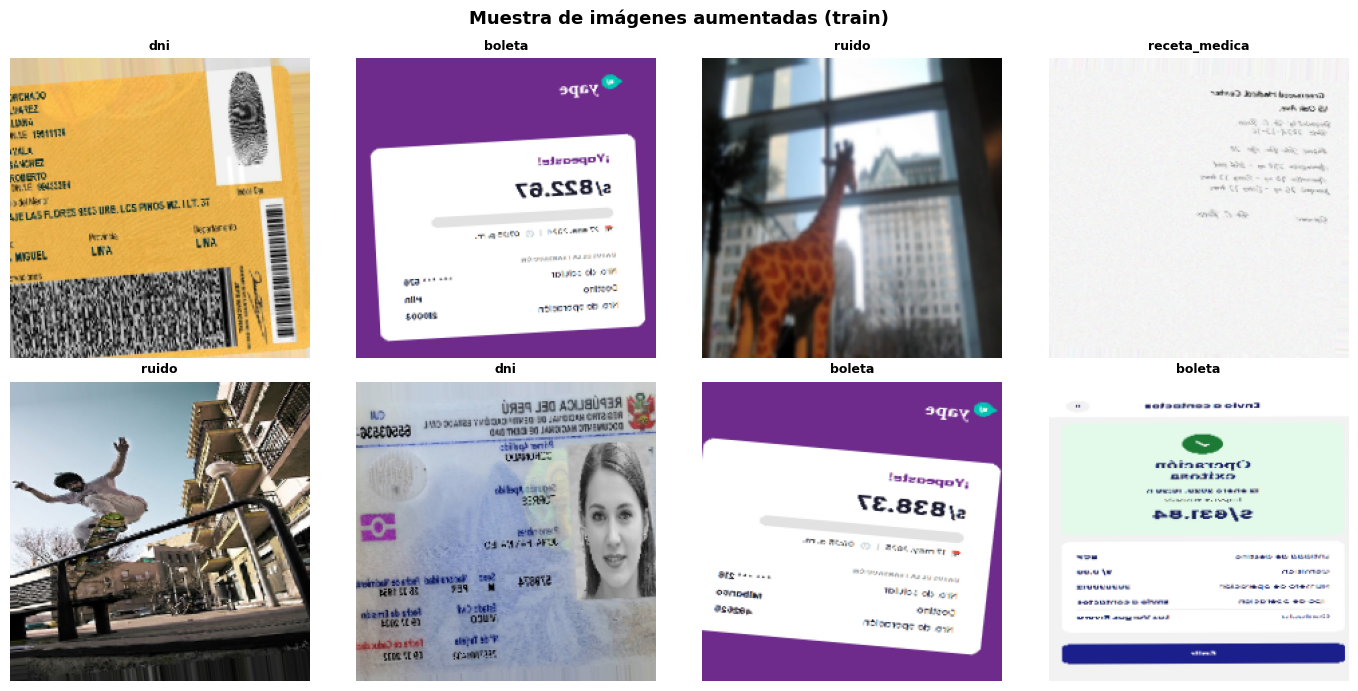

✅ Verificación visual del generador OK


In [ ]:
# Ver cómo quedan las imágenes después del augmentation
imgs, labels = next(flujo_train)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Muestra de imágenes aumentadas (train)', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    clase_idx = np.argmax(labels[i])
    ax.set_title(CLASES[clase_idx], fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()
print('✅ Verificación visual del generador OK')

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, Model

IMG_SIZE = 224

# Cargar MobileNetV2 preentrenado en ImageNet, sin la cabeza clasificadora
base_model = MobileNetV2(
    input_shape = (IMG_SIZE, IMG_SIZE, 3),
    include_top = False,    # quitamos la capa final de ImageNet
    weights     = 'imagenet'
)

# Congelar la base: no entrenaremos sus pesos todavía
base_model.trainable = False

print(f'✅ MobileNetV2 base cargado')
print(f'   Capas totales: {len(base_model.layers)}')
print(f'   Parámetros congelados: {base_model.count_params():,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ MobileNetV2 base cargado
   Capas totales: 154
   Parámetros congelados: 2,257,984


In [ ]:
# Construir el modelo completo
inputs  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)  # reducir mapas de características
x       = layers.Dropout(0.3)(x)              # regularización para evitar overfitting
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.2)(x)
outputs = layers.Dense(4, activation='softmax')(x)  # 4 clases

modelo = Model(inputs, outputs)

# Compilar
modelo.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print('✅ Modelo compilado')
print(f'\nResumen de capas entrenables:')
print(f'   Parámetros entrenables:   {sum([tf.size(w).numpy() for w in modelo.trainable_weights]):,}')
print(f'   Parámetros no entrenables: {sum([tf.size(w).numpy() for w in modelo.non_trainable_weights]):,}')

✅ Modelo compilado

Resumen de capas entrenables:
   Parámetros entrenables:   164,484
   Parámetros no entrenables: 2,257,984


In [ ]:
modelo.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

MODELO_PATH = '/content/drive/MyDrive/IA/dataset TB FINAL  IA/clasificador_doc/modelo_mobilenetv2.keras'

callbacks = [
    # Guarda el mejor modelo automáticamente
    ModelCheckpoint(
        filepath        = MODELO_PATH,
        monitor         = 'val_accuracy',
        save_best_only  = True,
        verbose         = 1
    ),
    # Detiene el entrenamiento si no mejora en 5 épocas
    EarlyStopping(
        monitor   = 'val_accuracy',
        patience  = 5,
        verbose   = 1,
        restore_best_weights = True
    ),
    # Reduce el learning rate si se estanca
    ReduceLROnPlateau(
        monitor  = 'val_accuracy',
        factor   = 0.5,
        patience = 3,
        verbose  = 1,
        min_lr   = 1e-6
    )
]

print('✅ Callbacks configurados')
print(f'   Modelo se guardará en: {MODELO_PATH}')

✅ Callbacks configurados
   Modelo se guardará en: /content/drive/MyDrive/IA/dataset TB FINAL  IA/clasificador_doc/modelo_mobilenetv2.keras


In [ ]:
import math

EPOCHS = 15

# Pasos por época
steps_train = math.ceil(len(df_train) / BATCH)
steps_test  = math.ceil(len(df_test)  / BATCH)

print(f'Pasos por época train: {steps_train}')
print(f'Pasos por época test:  {steps_test}')
print(f'Iniciando entrenamiento — fase 1 (cabeza)...\n')

historia = modelo.fit(
    flujo_train,
    steps_per_epoch  = steps_train,
    epochs           = EPOCHS,
    validation_data  = flujo_test,
    validation_steps = steps_test,
    callbacks        = callbacks
)

print('\n✅ Fase 1 completada')

Pasos por época train: 113
Pasos por época test:  29
Iniciando entrenamiento — fase 1 (cabeza)...

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9400 - loss: 0.1481
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /content/drive/MyDrive/IA/dataset TB FINAL  IA/clasificador_doc/modelo_mobilenetv2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/IA/dataset TB FINAL  IA/clasificador_doc/modelo_mobilenetv2.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 1200s 11s/step - accuracy: 0.9861 - loss: 0.0360 - val_accuracy: 1.0000 - val_loss: 1.5916e-04 - learning_rate: 0.0010
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 3.4306e-04
Epoch 2: val_accuracy did not improve from 1.00000
113/113 ━━━━━━━━━━━━━━━━━━━━ 324s 3s/step - accuracy: 1.0000 - loss: 3.0953e-04 - val_accuracy: 1.0000 - val_loss: 8.1073e-05 - learning_rate: 0.0010
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 1.8397e-04
Epoch 3

In [ ]:
print('Evaluando modelo en test...\n')
loss, accuracy = modelo.evaluate(flujo_test, steps=steps_test, verbose=1)
print(f'\n✅ Resultados en test:')
print(f'   Loss:     {loss:.6f}')
print(f'   Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

Evaluando modelo en test...

29/29 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 1.0000 - loss: 1.5916e-04

✅ Resultados en test:
   Loss:     0.000159
   Accuracy: 1.0000 (100.00%)


29/29 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step


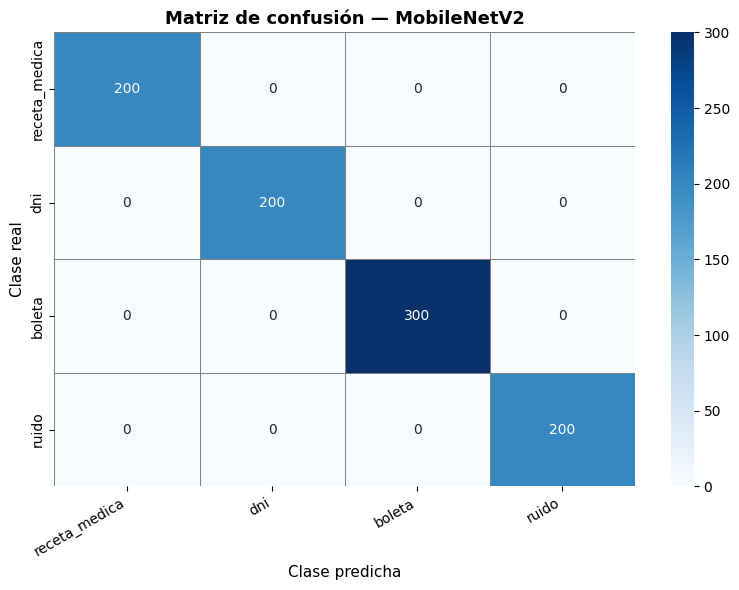

✅ Matriz de confusión guardada en Drive


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Obtener predicciones
flujo_test.reset()
y_pred_probs = modelo.predict(flujo_test, steps=steps_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_real = flujo_test.classes[:len(y_pred)]

# Matriz de confusión
cm = confusion_matrix(y_real, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASES, yticklabels=CLASES,
    linewidths=0.5, linecolor='gray'
)
ax.set_title('Matriz de confusión — MobileNetV2', fontsize=13, fontweight='bold')
ax.set_ylabel('Clase real', fontsize=11)
ax.set_xlabel('Clase predicha', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/IA/dataset TB FINAL  IA/clasificador_doc/matriz_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Matriz de confusión guardada en Drive')

In [ ]:
print('\n=== Reporte de clasificación ===\n')
print(classification_report(y_real, y_pred, target_names=CLASES, digits=4))


=== Reporte de clasificación ===

               precision    recall  f1-score   support

receta_medica     1.0000    1.0000    1.0000       200
          dni     1.0000    1.0000    1.0000       200
       boleta     1.0000    1.0000    1.0000       300
        ruido     1.0000    1.0000    1.0000       200

     accuracy                         1.0000       900
    macro avg     1.0000    1.0000    1.0000       900
 weighted avg     1.0000    1.0000    1.0000       900



In [ ]:
import os

MODELO_PATH = '/content/drive/MyDrive/IA/dataset TB FINAL  IA/clasificador_doc/modelo_mobilenetv2.keras'

# Verificar que el ModelCheckpoint ya lo guardó
if os.path.exists(MODELO_PATH):
    size_mb = os.path.getsize(MODELO_PATH) / (1024*1024)
    print(f'✅ Modelo principal ya guardado: {MODELO_PATH}')
    print(f'   Tamaño: {size_mb:.2f} MB')
else:
    modelo.save(MODELO_PATH)
    print(f'✅ Modelo guardado en: {MODELO_PATH}')

✅ Modelo principal ya guardado: /content/drive/MyDrive/IA/dataset TB FINAL  IA/clasificador_doc/modelo_mobilenetv2.keras
   Tamaño: 11.06 MB


In [ ]:
import json

config = {
    'modelo': 'MobileNetV2',
    'img_size': 224,
    'clases': CLASES,
    'clase_a_id': {c: i for i, c in enumerate(CLASES)},
    'id_a_clase': {str(i): c for i, c in enumerate(CLASES)},
    'accuracy_test': 1.0,
    'loss_test': 0.000159,
    'total_imagenes_entrenamiento': 3600,
    'total_imagenes_test': 900
}

CONFIG_PATH = '/content/drive/MyDrive/IA/dataset TB FINAL  IA/clasificador_doc/modelo_config.json'
with open(CONFIG_PATH, 'w', encoding='utf-8') as fp:
    json.dump(config, fp, indent=2, ensure_ascii=False)

print(f'✅ Configuración guardada: {CONFIG_PATH}')
print(f'\nContenido:')
print(json.dumps(config, indent=2, ensure_ascii=False))

✅ Configuración guardada: /content/drive/MyDrive/IA/dataset TB FINAL  IA/clasificador_doc/modelo_config.json

Contenido:
{
  "modelo": "MobileNetV2",
  "img_size": 224,
  "clases": [
    "receta_medica",
    "dni",
    "boleta",
    "ruido"
  ],
  "clase_a_id": {
    "receta_medica": 0,
    "dni": 1,
    "boleta": 2,
    "ruido": 3
  },
  "id_a_clase": {
    "0": "receta_medica",
    "1": "dni",
    "2": "boleta",
    "3": "ruido"
  },
  "accuracy_test": 1.0,
  "loss_test": 0.000159,
  "total_imagenes_entrenamiento": 3600,
  "total_imagenes_test": 900
}


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np, random

# Cargar modelo desde Drive (simula cómo lo usará ALDIMI)
modelo_cargado = load_model(MODELO_PATH)
print('✅ Modelo cargado desde Drive correctamente\n')

# Tomar 1 imagen al azar de cada clase del test
print('=== Prueba de inferencia ===\n')
for clase in CLASES:
    carpeta = os.path.join(DESTINO, clase, 'test')
    archivo = random.choice(os.listdir(carpeta))
    ruta    = os.path.join(carpeta, archivo)

    # Preprocesar igual que en entrenamiento
    img = image.load_img(ruta, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predecir
    pred = modelo_cargado.predict(img_array, verbose=0)
    clase_pred = CLASES[np.argmax(pred)]
    confianza  = np.max(pred) * 100

    estado = '✅' if clase_pred == clase else '❌'
    print(f'{estado} Real: {clase:15s} → Predicho: {clase_pred:15s} ({confianza:.2f}% confianza)')

✅ Modelo cargado desde Drive correctamente

=== Prueba de inferencia ===

✅ Real: receta_medica   → Predicho: receta_medica   (100.00% confianza)
✅ Real: dni             → Predicho: dni             (100.00% confianza)
✅ Real: boleta          → Predicho: boleta          (99.99% confianza)
✅ Real: ruido           → Predicho: ruido           (99.63% confianza)
